# Laboratorio 7 — Etapa 2: Simulación del Álbum FIFA 2026 (Escenario Real)
## MM3014 Teoría de Probabilidades · Universidad del Valle de Guatemala
## Diego Andre Calderon Salazar 241263 
## Pedro Julio Caso 241286 
---

### Introducción

Con la experiencia de la Etapa 1, ahora simulamos el álbum **real** del Mundial FIFA 2026 con $N = 980$ estampas distintas y $S = 7$ por sobre. Esta etapa aborda los cuatro objetivos del laboratorio:

| # | Objetivo |
|---|----------|
| 1 | Estimar el número esperado de sobres para completar la colección |
| 2 | Estimar el costo total esperado (individual vs. cajas) |
| 3 | Calcular la probabilidad de éxito con un presupuesto limitado |
| 4 | Cuantificar el efecto del intercambio de estampas repetidas |

**Precios:**
- Sobre individual: **Q 9.50**
- Caja de 104 sobres: **Q 975.00** (equivale a Q 9.375/sobre)

**Semilla obligatoria:** `2026`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## Parámetros del problema

In [11]:
N = 980 # total de estampas distintas para llenar el album
S = 7 # estampas por sobre
R = 10000
SEED = 2026

PRECIO_SOBRE = 9.5
PRECIO_CAJA = 975.00
SOBRES_POR_CAJA = 104
PRECIO_SOBRE_CAJA = PRECIO_CAJA / SOBRES_CAJA



---
## Objetivo 1: Número esperado de sobres

### Simulación base (sin intercambio)

In [6]:
np.random.seed(SEED)

sobres_result    = np.zeros(R, dtype=int)
repetidas_result = np.zeros(R, dtype=int)

for i in range(R):
    album     = np.zeros(N, dtype=bool)
    sobres    = 0
    repetidas = 0
    count     = 0

    while count < N:
        stickers   = np.random.choice(N, size=S, replace=False)
        nuevas     = ~album[stickers]
        n_nuevas   = int(nuevas.sum())
        repetidas += S - n_nuevas
        count     += n_nuevas
        album[stickers] = True
        sobres += 1

    sobres_result[i]    = sobres
    repetidas_result[i] = repetidas

print(f"Simulación completa: {R:,} repeticiones.")

Simulación completa: 10,000 repeticiones.


In [8]:
# Estadísticas empíricas
media_sobres = np.mean(sobres_result)
std_sobres   = np.std(sobres_result)
media_rep    = np.mean(repetidas_result)
std_rep      = np.std(repetidas_result)
min_teorico  = math.ceil(N / S)

# Teoría del coleccionista
GAMMA       = 0.5772156649015329
H_N         = sum(1/k for k in range(1, N + 1))
E_T_teorico = (N / S) * H_N
E_rep_teo   = N * (H_N - 1)



print(f"  RESULTADOS ETAPA 2  (N={N}, S={S}, R={R:,})")
print(f"\n  Sobres necesarios:")
print(f"    Media simulada     : {media_sobres:.2f}")
print(f"    Desv. estándar     : {std_sobres:.2f}")
print(f"    Valor teórico E[T] : {E_T_teorico:.2f}")
print(f"    Error relativo     : {abs(E_T_teorico-media_sobres)/E_T_teorico*100:.3f}%")
print(f"\n  Estampas repetidas:")
print(f"    Media simulada     : {media_rep:.2f}")
print(f"    Valor teórico      : {E_rep_teo:.2f}")
print(f"\n  Mínimo teórico (sin repetidas): {min_teorico} sobres  (⌈{N}/{S}⌉)")


  RESULTADOS ETAPA 2  (N=980, S=7, R=10,000)

  Sobres necesarios:
    Media simulada     : 1042.70
    Desv. estándar     : 177.82
    Valor teórico E[T] : 1045.14
    Error relativo     : 0.234%

  Estampas repetidas:
    Media simulada     : 6318.87
    Valor teórico      : 6335.97

  Mínimo teórico (sin repetidas): 140 sobres  (⌈980/7⌉)


### Visualización 1 — Distribución de sobres necesarios

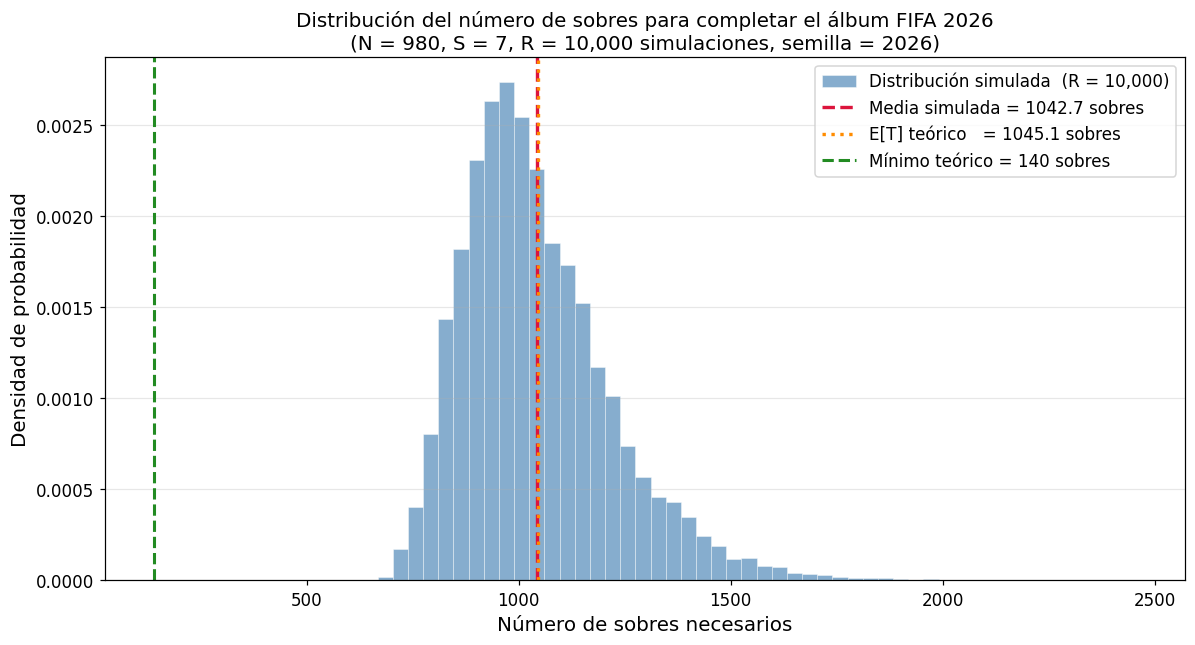

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(sobres_result, bins=50, density=True, alpha=0.65,
        color='steelblue', edgecolor='white', linewidth=0.4,
        label=f'Distribución simulada  (R = {R:,})')

ax.axvline(media_sobres, color='crimson', linestyle='--', linewidth=2.2,
           label=f'Media simulada = {media_sobres:.1f} sobres')
ax.axvline(E_T_teorico, color='darkorange', linestyle=':', linewidth=2.2,
           label=f'E[T] teórico   = {E_T_teorico:.1f} sobres')
ax.axvline(min_teorico, color='forestgreen', linestyle='--', linewidth=2.0,
           label=f'Mínimo teórico = {min_teorico} sobres')

ax.set_xlabel('Número de sobres necesarios', fontsize=13)
ax.set_ylabel('Densidad de probabilidad', fontsize=13)
ax.set_title(
    f'Distribución del número de sobres para completar el álbum FIFA 2026\n'
    f'(N = {N}, S = {S}, R = {R:,} simulaciones, semilla = {SEED})',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## Objetivo 2: Análisis de costos

Se comparan dos estrategias de compra:
- **Individual:** comprar sobres uno a uno a Q 9.50.
- **Por cajas:** comprar cajas de 104 sobres a Q 975.00 (redondeando hacia arriba).
- **Mixta:** comprar cajas hasta cubrir la mayor parte, complementar con individuales.

In [12]:
def costo_individual(n_sobres):
    return n_sobres * PRECIO_SOBRE

def costo_por_cajas(n_sobres):
    """Comprar sólo cajas completas (puede sobrar presupuesto)."""
    n_cajas = math.ceil(n_sobres / SOBRES_POR_CAJA)
    return n_cajas * PRECIO_CAJA

def costo_mixto(n_sobres):
    """Cajas completas + individuales para los sobres restantes."""
    n_cajas      = n_sobres // SOBRES_POR_CAJA
    n_individuales = n_sobres % SOBRES_POR_CAJA
    return n_cajas * PRECIO_CAJA + n_individuales * PRECIO_SOBRE

costos_individual = np.array([costo_individual(s) for s in sobres_result])
costos_cajas      = np.array([costo_por_cajas(s) for s in sobres_result])
costos_mixto      = np.array([costo_mixto(s) for s in sobres_result])

sep = "-" * 58
print(f"{'Estrategia':<22} {'Media (Q)':>12} {'Std (Q)':>10} {'Mín (Q)':>10} {'Máx (Q)':>10}")
print(sep)
for nombre, arr in [("Individual", costos_individual),
                    ("Por cajas", costos_cajas),
                    ("Mixta", costos_mixto)]:
    print(f"{nombre:<22} {np.mean(arr):>12.2f} {np.std(arr):>10.2f} "
          f"{np.min(arr):>10.2f} {np.max(arr):>10.2f}")
print(sep)
ahorro_cajas = np.mean(costos_individual) - np.mean(costos_cajas)
ahorro_mixto = np.mean(costos_individual) - np.mean(costos_mixto)
print(f"\nAhorro esperado (Individual - Por cajas) : Q {ahorro_cajas:>8.2f}")
print(f"Ahorro esperado (Individual - Mixta)     : Q {ahorro_mixto:>8.2f}")

Estrategia                Media (Q)    Std (Q)    Mín (Q)    Máx (Q)
----------------------------------------------------------
Individual                  9905.61    1689.28    6336.50   23322.50
Por cajas                  10255.54    1690.73    6825.00   23400.00
Mixta                       9781.74    1667.07    6258.50   23023.50
----------------------------------------------------------

Ahorro esperado (Individual - Por cajas) : Q  -349.93
Ahorro esperado (Individual - Mixta)     : Q   123.87


### Visualización 2 — Distribución de costos por estrategia

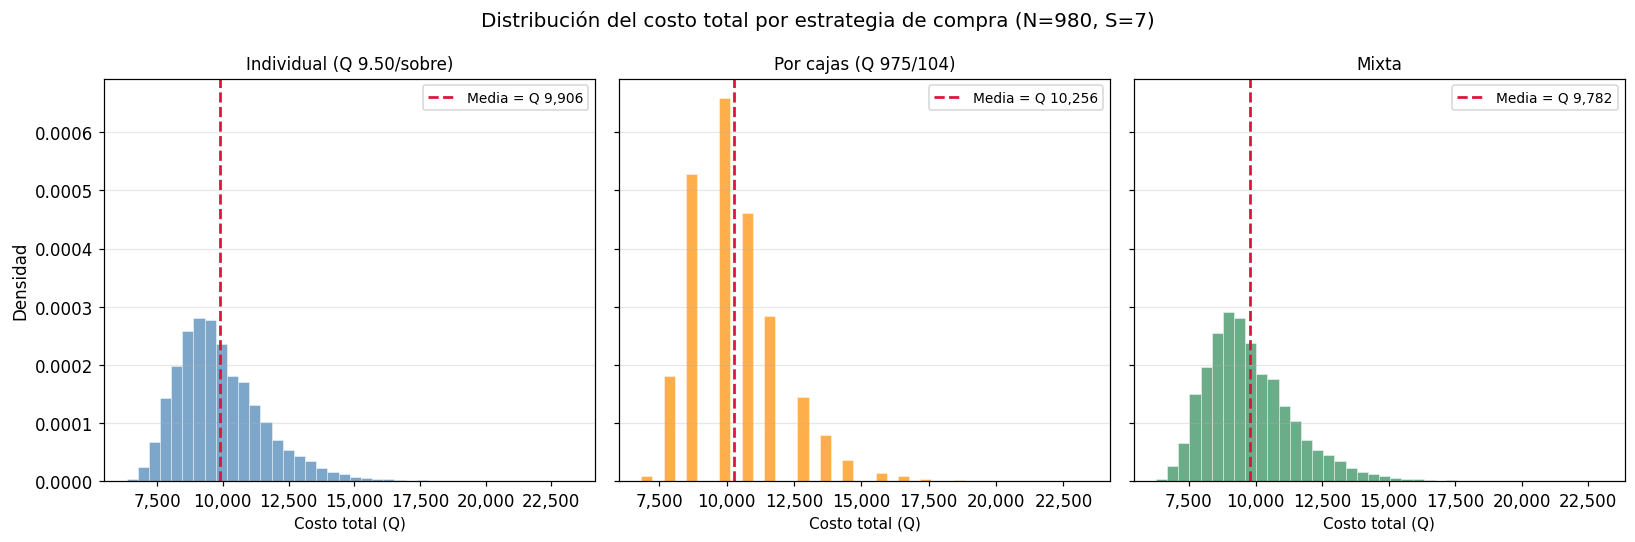

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datos_plot = [
    (costos_individual, 'Individual (Q 9.50/sobre)', 'steelblue'),
    (costos_cajas,      'Por cajas (Q 975/104)',      'darkorange'),
    (costos_mixto,      'Mixta',                      'seagreen'),
]

for ax, (arr, titulo, color) in zip(axes, datos_plot):
    ax.hist(arr, bins=40, density=True, alpha=0.7, color=color,
            edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(arr), color='crimson', linestyle='--', linewidth=1.8,
               label=f'Media = Q {np.mean(arr):,.0f}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Costo total (Q)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_ylabel('Densidad', fontsize=11)
fig.suptitle('Distribución del costo total por estrategia de compra (N=980, S=7)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Objetivo 3: Probabilidad de éxito con presupuesto limitado

¿Con qué probabilidad se puede completar el álbum dado un presupuesto fijo?

Para cada presupuesto $B$, el máximo de sobres comprables es:
- **Individual:** $\lfloor B / 9.50 \rfloor$ sobres
- **Por cajas:** $\lfloor B / 975 \rfloor \times 104$ sobres

### Visualización 3 — Curva de probabilidad de éxito vs presupuesto

---
## Objetivo 4: Efecto del intercambio de estampas repetidas

El intercambio permite convertir estampas repetidas en estampas necesarias. Se modela con un parámetro $p_{\text{intercambio}}$: fracción de repetidas que se puede intercambiar exitosamente en cada sobre comprado.

Se comparan tres escenarios:
- $p = 0$: Sin intercambio (baseline)
- $p = 0.25$: Intercambio moderado
- $p = 0.50$: Intercambio activo

### Visualización 4 — Comparativa de distribuciones con y sin intercambio

---
## Resumen final

---
## Preguntas de análisis

### Pregunta 1
**Compare el valor teórico $E[T]$ con la media simulada para N=980. ¿El error relativo es mayor o menor que en la Etapa 1 (N=100)? ¿Por qué?**

### Pregunta 2
**¿Cuántas cajas completas necesitaría comprar en promedio? ¿Cuánto se ahorra vs. compra individual?**

### Pregunta 3
**¿Qué presupuesto necesitaría para tener una probabilidad del 90% de completar el álbum comprando individualmente?**

### Pregunta 4
**¿El intercambio al 50% reduce el costo a la mitad? ¿Cómo explica la relación entre tasa de intercambio y reducción de sobres?**